In [1]:
token = "0_1D7een2oVstB7_UOzYwx8feVUsh3k0a9H0GqaaH7IgklbJqSELb7eKopLrxEl!" # M2M token from ERAS 

In [3]:
import ee
import geemap
# Authenticate
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='ee-anna-lackner')
print(ee.String('Hello from the Earth Engine servers!').getInfo())

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_0JLhFqfSY1uiEaW?source=Init


Hello from the Earth Engine servers!


# acessing and understnading Google earth engine

In [40]:


# convert code snippet to python
js_snippet = """
// Define an area of interest geometry with a global non-polar extent.
var aoi = ee.Geometry.Polygon(
  [[[-179.0, 78.0], [-179.0, -58.0], [179.0, -58.0], [179.0, 78.0]]], null,
  false);

// Import hourly predicted temperature image collection for northern winter
// solstice. Note that predictions extend for 384 hours; limit the collection
// to the first 24 hours.
var tempCol = ee.ImageCollection('NOAA/GFS0P25')
  .filterDate('2018-12-22', '2018-12-23')
  .limit(24)
  .select('temperature_2m_above_ground');

// Define arguments for animation function parameters.
var videoArgs = {
  dimensions: 768,
  region: aoi,
  framesPerSecond: 7,
  crs: 'EPSG:3857',
  min: -40.0,
  max: 35.0,
  palette: ['blue', 'purple', 'cyan', 'green', 'yellow', 'red']
};

// Print the animation to the console as a ui.Thumbnail using the above defined
// arguments. Note that ui.Thumbnail produces an animation when the first input
// is an ee.ImageCollection instead of an ee.Image.
print(ui.Thumbnail(tempCol, videoArgs));

// Alternatively, print a URL that will produce the animation when accessed.
print(tempCol.getVideoThumbURL(videoArgs));
"""

geemap.js_snippet_to_py(js_snippet)




In [5]:
import ee

# Initialize the Earth Engine module.
ee.Initialize()

# Define an area of interest geometry with a global non-polar extent.
aoi = ee.Geometry.Polygon(
    [[[-179.0, 78.0], [-179.0, -58.0], [179.0, -58.0], [179.0, 78.0]]], None,
    False
)

# Import hourly predicted temperature image collection for northern winter
# solstice. Note that predictions extend for 384 hours; limit the collection
# to the first 24 hours.
tempCol = ee.ImageCollection('NOAA/GFS0P25') \
    .filterDate('2018-12-22', '2018-12-23') \
    .limit(24) \
    .select('temperature_2m_above_ground')

# Define arguments for animation function parameters.
videoArgs = {
    "dimensions": 768,
    "region": aoi,
    "framesPerSecond": 7,
    "crs": 'EPSG:3857',
    "min": -40.0,
    "max": 35.0,
    "palette": ['blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

# Get the URL for the animation.
video_url = tempCol.getVideoThumbURL(videoArgs)
print("Animation URL:", video_url)


Animation URL: https://earthengine.googleapis.com/v1/projects/ee-anna-lackner/videoThumbnails/daae03c90c7b9faaeb06796a49eaa400-45a0e8cd796733e917da4f904b60ee87:getPixels


In [4]:
catch_shp = "shapefile/example.shp"
catch = geemap.shp_to_ee(catch_shp)

m = geemap.Map()

dataset = ee.ImageCollection('LANDSAT/COMPOSITES/C02/T1_L2_8DAY_NDVI') \
.filterDate('2015-01-01', '2017-12-31') \
.filterBounds(catch.geometry())
colorized = dataset.select('NDVI')
colorizedVis = {
    "min": 0,
    "max": 1,
    "palette": [
    'ffffff', 'ce7e45', 'df923d', 'f1b555', 'fcd163', '99b718', '74a901',
    '66a000', '529400', '3e8601', '207401', '056201', '004c00', '023b01',
    '012e01', '011d01', '011301'
    ],
}
m.setCenter(18.834857,64.315246 , 8)
m.addLayer(colorized, colorizedVis, 'Colorized')
m.addLayer(catch, {}, "catch")

m

Map(center=[64.315246, 18.834857], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…

In [16]:
import ee
import geemap

# Initialize Earth Engine
ee.Initialize()

# Load the catchment shapefile as an Earth Engine object.
catch_shp = "shapefile/example.shp"
catch = geemap.shp_to_ee(catch_shp)

# Define the map center to somewhere in Sweden and set zoom level.
m = geemap.Map(center=[64.315246, 18.834857], zoom=8)

# Load Landsat NDVI dataset and filter it over the catchment area for a specific date range.
dataset = ee.ImageCollection('LANDSAT/COMPOSITES/C02/T1_L2_8DAY_NDVI') \
    .filterDate('2021-01-01', '2022-12-31') \
    .filterBounds(catch.geometry()) \
    .select('NDVI')

# Define visualization parameters for NDVI.
colorizedVis = {
    "min": 0,
    "max": 1,
    "palette": [
        'ffffff', 'ce7e45', 'df923d', 'f1b555', 'fcd163', '99b718', '74a901',
        '66a000', '529400', '3e8601', '207401', '056201', '004c00', '023b01',
        '012e01', '011d01', '011301'
    ],
}

# Add layers to the map for visualization.
m.addLayer(dataset.median(), colorizedVis, 'NDVI Median')
m.addLayer(catch, {}, "Catchment Area")

# Define a smaller region, e.g., a 500,000-meter buffer around the catchment's centroid, with an error margin.

region = catch.geometry().centroid(maxError=10).buffer(5000).bounds().getInfo()['coordinates']


videoArgs = {
    "dimensions": 512,
    "region": region,  # Use the reduced region
    "framesPerSecond": 2,
    "crs": 'EPSG:3857',
    "min": 0,
    "max": 1,
    "palette": colorizedVis['palette']
}


# Generate the video thumbnail URL for the NDVI animation.
video_url = dataset.getVideoThumbURL(videoArgs)
print("NDVI Animation URL:", video_url)

# Display the map
m


NDVI Animation URL: https://earthengine.googleapis.com/v1/projects/ee-anna-lackner/videoThumbnails/b89faa7238eca3cc8cabfec457d54901-827c1f726c4a0de584642d70a33cbd70:getPixels


Map(center=[64.315246, 18.834857], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…

# NDVI for Points

### Random fake input 

Sweden boundary has been saved as 'sweden_boundary.geojson'.


C:\Users\anlr0006\AppData\Local\Temp\ipykernel_38424\2126705382.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  sweden_boundary = sweden_gdf.geometry.unary_union


Random points saved locally as 'fake_input.shp'.


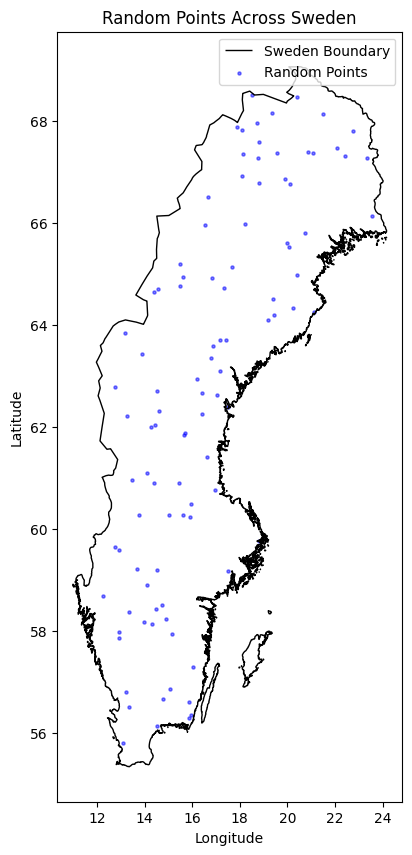

Map saved as 'sweden_random_points_map.png'.


In [26]:
import ee
import random
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import json

# Initialize the Earth Engine module
ee.Initialize()

# Step 1: Use GEE to fetch the Sweden boundary as GeoJSON
# Fetch the Sweden boundary from GEE
sweden = ee.FeatureCollection("FAO/GAUL/2015/level0").filter(ee.Filter.eq("ADM0_NAME", "Sweden"))

# Export the Sweden boundary as GeoJSON
sweden_geojson = sweden.geometry().getInfo()

# Save the GeoJSON to a local file (for later use in GeoPandas)
with open('sweden_boundary.geojson', 'w') as f:
    json.dump(sweden_geojson, f)

print("Sweden boundary has been saved as 'sweden_boundary.geojson'.")

# Step 2: Generate random points within the Sweden boundary using Python
# Load the Sweden boundary GeoJSON into GeoPandas
sweden_gdf = gpd.read_file('sweden_boundary.geojson')

# Get the boundary of Sweden
sweden_boundary = sweden_gdf.geometry.unary_union

# Function to generate random points within the boundary of Sweden
def generate_random_points(n, region):
    points = []
    min_lon, min_lat, max_lon, max_lat = region.bounds  # Get bounding box coordinates
    
    # Generate random points within the bounding box and check if they are inside Sweden
    while len(points) < n:
        lon = random.uniform(min_lon, max_lon)
        lat = random.uniform(min_lat, max_lat)
        point = Point(lon, lat)
        
        # Check if the point is within the Sweden boundary
        if region.contains(point):
            points.append((lon, lat))
    
    return points

# Generate 100 random points within Sweden's boundary
random_points = generate_random_points(100, sweden_boundary)

# Convert the random points to a GeoDataFrame and add sample identifier (idx)
points_gdf = gpd.GeoDataFrame(
    geometry=[Point(lon, lat) for lon, lat in random_points],
    crs="EPSG:4326"  # WGS84 coordinate system
)

# Add a unique sample identifier (idx) for each point
points_gdf['sample_id'] = points_gdf.index  # Use the index as the unique identifier

# Save the points as a shapefile
shapefile_name = "fake_input.shp"
points_gdf.to_file(shapefile_name, driver="ESRI Shapefile")
print(f"Random points saved locally as '{shapefile_name}'.")

# Step 3: Plot Sweden boundary and random points
fig, ax = plt.subplots(figsize=(10, 10))
sweden_gdf.boundary.plot(ax=ax, linewidth=1, color="black", label="Sweden Boundary")
points_gdf.plot(ax=ax, markersize=5, color="blue", alpha=0.5, label="Random Points")

# Customize plot appearance
ax.set_title("Random Points Across Sweden")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()

# Optionally, save the plot as an image
output_map_file = "sweden_random_points_map.png"
plt.savefig(output_map_file, format='png')

# Display the map
plt.show()

print(f"Map saved as '{output_map_file}'.")


## Finding NDVI for points in shapefile

In [2]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [41]:
import os
import geopandas as gpd

zip_catch = "catch_316.zip"

os.chdir("C:/Users/anlr0006/Repositories/top-down/Shapefiles")

# Load the shapefiles from the ZIP files
gdf_catch = gpd.read_file(f"zip://{zip_catch}")

gdf_catch.to_crs(epsg=4326, inplace=True)

## Catchment time series of NDVI

In [ ]:
import ee
import pandas as pd
import geopandas as gpd
from datetime import datetime

# Initialize the Earth Engine API
ee.Initialize()

# Function to load the shapefile and convert it to a FeatureCollection
def geo_to_ee(gdf):
    features = []
    for idx, geometry in gdf.geometry.items():
        try:
            mvm_id = gdf.loc[idx, 'mvm_id']  # Extract mvm_id for this row
            
            # Check the geometry type and convert accordingly
            if geometry.geom_type == 'Polygon':
                ee_geom = ee.Geometry.Polygon(list(geometry.exterior.coords))
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            elif geometry.geom_type == 'MultiPolygon':
                polygons = [ee.Geometry.Polygon(list(poly.exterior.coords)) for poly in geometry.geoms]
                ee_geom = ee.Geometry.MultiPolygon(polygons)
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            elif geometry.geom_type == 'Point':
                ee_geom = ee.Geometry.Point([geometry.x, geometry.y])
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            else:
                print(f"Skipping unsupported geometry type: {geometry.geom_type}")
        except Exception as e:
            print(f"Error processing geometry {idx}: {e}")
    return ee.FeatureCollection(features)

# Load your shapefile (replace 'gdf_catch' with the actual GeoDataFrame name)
gdf = gdf_catch.iloc[2:3]  # Example of selecting the first two rows for demonstration

# Print the DataFrame to check its structure
print("GeoDataFrame structure:")
print(gdf)
print(gdf.crs)

# Convert GeoDataFrame to Earth Engine FeatureCollection
catchments = geo_to_ee(gdf)

# Define the Landsat 8 NDVI Composite dataset (8-day composite)
Landsat_NDVI = ee.ImageCollection('LANDSAT/COMPOSITES/C02/T1_L2_8DAY_NDVI')

# Define the months and years for which you want to calculate the NDVI (January to December, 2020-2021)
months = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
years = [2020, 2021]

# Function to generate the correct last day of the month (handling leap years)
def get_last_day_of_month(year, month):
    if month == "02":  # Special handling for February (Leap Year)
        if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)):  # Leap year check
            return f"{year}-{month}-29"  # Leap year (February 29)
        else:
            return f"{year}-{month}-28"  # Non-leap year (February 28)
    elif month in ["04", "06", "09", "11"]:  # 30-day months
        return f"{year}-{month}-30"
    else:  # 31-day months
        return f"{year}-{month}-31"

# Store results in a list
results = []

# Loop through each geometry (catchment) and calculate NDVI time series for each month and year
for idx, geometry in gdf.iterrows():
    try:
        mvm_id = geometry['mvm_id']
        print(f"Processing geometry with mvm_id: {mvm_id}")
        
        # Convert the geometry to an Earth Engine object
        shape = geo_to_ee(gdf.loc[[idx]])  # Use the current row for the geometry
        print(f"Shape for mvm_id {mvm_id} converted to Earth Engine FeatureCollection.")
        
        # Loop through each year and month to create the time series
        for year in years:
            for month in months:
                print(f"Processing month: {month} for mvm_id {mvm_id} in {year}")
                
                # Initialize the collection for the current month
                image_collection = None
                
                start_date = f"{year}-{month}-01"
                end_date = get_last_day_of_month(year, month)
                
                # Filter the Landsat NDVI data for the current month and year
                date_filter = ee.Filter.date(start_date, end_date)
                
                # Filter Landsat data by date and geometry bounds
                landsat_filtered = Landsat_NDVI \
                    .filter(date_filter) \
                    .filterBounds(shape)
                
                # Check how many images are available for the current month
                image_count = landsat_filtered.size().getInfo()
                print(f"Number of images for {month}-{year}: {image_count}")
                
                # If no images are available, skip to the next month
                if image_count == 0:
                    print(f"No images for {month}-{year} and mvm_id {mvm_id}. Skipping.")
                    continue

                # Apply the reducers separately: mean, median, and stdDev
                ndvi_mean = landsat_filtered.reduce(ee.Reducer.mean())
                ndvi_median = landsat_filtered.reduce(ee.Reducer.median())
                ndvi_stdDev = landsat_filtered.reduce(ee.Reducer.stdDev())

                # Now apply reduceRegions for each of the statistics
                stats_mean = ndvi_mean.reduceRegions(
                    collection=shape,
                    reducer=ee.Reducer.mean(),
                    scale=30,  # Set scale to 30 meters (Landsat resolution)
                    tileScale=2
                )

                stats_median = ndvi_median.reduceRegions(
                    collection=shape,
                    reducer=ee.Reducer.median(),
                    scale=30,
                    tileScale=2
                )

                stats_stdDev = ndvi_stdDev.reduceRegions(
                    collection=shape,
                    reducer=ee.Reducer.stdDev(),
                    scale=30,
                    tileScale=2
                )

                try:
                    # Get the results for each statistic (mean, median, stdDev)
                    mean_info = stats_mean.getInfo()
                    median_info = stats_median.getInfo()
                    stdDev_info = stats_stdDev.getInfo()

                    # Check if the results contain features
                    if 'features' in mean_info and len(mean_info['features']) > 0:
                        # Extract and append results for each mvm_id, month, and year
                        for i in range(len(mean_info['features'])):
                            feature_data = {
                                'month': month,
                                'year': year,
                                'mvm_id': mvm_id,
                                'NDVI_mean': mean_info['features'][i]['properties'].get('mean', None),
                                'NDVI_median': median_info['features'][i]['properties'].get('median', None),
                                'NDVI_stdDev': stdDev_info['features'][i]['properties'].get('stdDev', None),
                                'coordinates': mean_info['features'][i]['geometry']['coordinates']
                            }
                            results.append(feature_data)

                except Exception as e:
                    print(f"Error computing statistics for {month}-{year} and mvm_id {mvm_id}: {str(e)}")
                    # If error occurs, append None for NDVI statistics
                    feature_data = {
                        'month': month,
                        'year': year,
                        'mvm_id': mvm_id,
                        'NDVI_mean': None,
                        'NDVI_median': None,
                        'NDVI_stdDev': None,
                        'coordinates': None
                    }
                    results.append(feature_data)

    except Exception as e:
        print(f"Error processing mvm_id {gdf.loc[idx, 'mvm_id']}: {e}")

# Convert results to a pandas DataFrame
df = pd.DataFrame(results)

# Display the final DataFrame
print(df)

out_path = r"C:\Users\anlr0006\Repositories\DOC_catchments\Output\NDVI.csv"

df.to_csv(out_path, index = False)


GeoDataFrame structure:
   mvm_id        lat       lon          AU_CD   Shape_Leng     Shape_Area  \
2  1815.0  6330290.0  473043.0  633181-142382  2780.197525  214447.493165   

                                            geometry  
2  POLYGON ((14.55448 57.11567, 14.5554 57.11509,...  
EPSG:4326
Processing geometry with mvm_id: 1815.0
Shape for mvm_id 1815.0 converted to Earth Engine FeatureCollection.
Processing month: 01 for mvm_id 1815.0 in 2020
Number of images for 01-2020: 4
Processing month: 02 for mvm_id 1815.0 in 2020
Number of images for 02-2020: 4
Processing month: 03 for mvm_id 1815.0 in 2020
Number of images for 03-2020: 4
Processing month: 04 for mvm_id 1815.0 in 2020
Number of images for 04-2020: 3
Processing month: 05 for mvm_id 1815.0 in 2020
Number of images for 05-2020: 3
Processing month: 06 for mvm_id 1815.0 in 2020
Number of images for 06-2020: 4
Processing month: 07 for mvm_id 1815.0 in 2020
Number of images for 07-2020: 4
Processing month: 08 for mvm_id 1815.0 

## With video

In [1]:
import ee
import geopandas as gpd

# Initialize the Earth Engine API
ee.Initialize()

# Load your GeoDataFrame (gdf) with the shapes
# Replace with the correct file path

# Select the third row (index 2) to get the shape you want
single_shape = gdf_catch.iloc[3:4]  # Get the third row

# Function to convert GeoDataFrame geometry to Earth Engine FeatureCollection
def geo_to_ee(gdf):
    features = []
    for idx, geometry in gdf.geometry.items():
        try:
            mvm_id = gdf.loc[idx, 'mvm_id']  # Extract mvm_id for this row
            
            # Check the geometry type and convert accordingly
            if geometry.geom_type == 'Polygon':
                ee_geom = ee.Geometry.Polygon(list(geometry.exterior.coords))
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            elif geometry.geom_type == 'MultiPolygon':
                polygons = [ee.Geometry.Polygon(list(poly.exterior.coords)) for poly in geometry.geoms]
                ee_geom = ee.Geometry.MultiPolygon(polygons)
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            elif geometry.geom_type == 'Point':
                ee_geom = ee.Geometry.Point([geometry.x, geometry.y])
                features.append(ee.Feature(ee_geom).set('mvm_id', mvm_id))  # Add 'mvm_id' as property
            else:
                print(f"Skipping unsupported geometry type: {geometry.geom_type}")
        except Exception as e:
            print(f"Error processing geometry {idx}: {e}")
    return ee.FeatureCollection(features)

# Convert the GeoDataFrame row to an Earth Engine FeatureCollection
catchment = geo_to_ee(single_shape)

# Define the Landsat 8 NDVI dataset (8-day composite)
Landsat_NDVI = ee.ImageCollection('LANDSAT/COMPOSITES/C02/T1_L2_8DAY_NDVI')

# Define the months and years for which you want to calculate the NDVI (January to December, 2020-2021)
months = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
years = [2020, 2021]

# Function to generate the correct last day of the month (handling leap years)
def get_last_day_of_month(year, month):
    if month == "02":  # Special handling for February (Leap Year)
        if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)):  # Leap year check
            return f"{year}-{month}-29"  # Leap year (February 29)
        else:
            return f"{year}-{month}-28"  # Non-leap year (February 28)
    elif month in ["04", "06", "09", "11"]:  # 30-day months
        return f"{year}-{month}-30"
    else:  # 31-day months
        return f"{year}-{month}-31"

# Function to create NDVI video for a given catchment
def create_ndvi_video(catchment_fc):
    # Define the visualization parameters for NDVI (color palette)
    vis_params = {
        'min': -0.2,
        'max': 0.8,
        'palette': ['blue', 'white', 'green']
    }
    
    # List to store the images (NDVI for each month)
    images = []
    
    # Loop through each year and month to generate the NDVI images
    for year in years:
        for month in months:
            start_date = f"{year}-{month}-01"
            end_date = get_last_day_of_month(year, month)
            
            # Filter Landsat NDVI data for the current month and year
            date_filter = ee.Filter.date(start_date, end_date)
            
            # Extract the geometry of the catchment for the current mvm_id
            geometry = catchment_fc.first().geometry()  # Extract the first feature's geometry
            
            # Ensure we have a valid geometry (check if it's not None)
            if geometry is not None:
                landsat_filtered = Landsat_NDVI.filter(date_filter).filterBounds(geometry)
                
                # Check if there is any data for the filtered range
                if landsat_filtered.size().getInfo() > 0:
                    ndvi_image = landsat_filtered.mean().visualize(**vis_params)
                    images.append(ndvi_image)
                else:
                    print(f"No Landsat data for {start_date} to {end_date}")
    
    # Get the bounding box of the geometry for a more focused region
    bbox = geometry.bounds().getInfo()  # This returns a dictionary describing the Polygon
    
    # Extract the coordinates from the bounding box (which is a Polygon)
    try:
        # The bounding box coordinates are in the form of a list of lists (Polygon coordinates)
        coords = bbox['coordinates'][0]
        
        # Extract min and max values from the coordinates
        minx = min([coord[0] for coord in coords])
        miny = min([coord[1] for coord in coords])
        maxx = max([coord[0] for coord in coords])
        maxy = max([coord[1] for coord in coords])
        
        bbox_coords = [minx, miny, maxx, maxy]
        print("Extracted Bounding Box:", bbox_coords)
    except Exception as e:
        print(f"Error extracting bounding box coordinates: {e}")
        return None
    
    # Create the region geometry using the extracted bounding box coordinates
    region = ee.Geometry.Rectangle(bbox_coords)
    print("Region:", region.getInfo())
    
    # Create a video from the list of images (frames)
    video_args = {
        'dimensions': 720,
        'region': region,  # Using the bounding box as the region
        'framesPerSecond': 2,  # Set the frames per second for the animation
        'crs': 'EPSG:4326',
        'min': -0.2,
        'max': 0.8
    }
    
    try:
        # Generate video URL or export video to Google Drive
        video_url = ee.ImageCollection(images).getVideoThumbURL(video_args)
        print(f"Video URL: {video_url}")
        return video_url
    except Exception as e:
        print(f"Error generating video: {e}")
        return None

# Generate NDVI video URL for the selected catchment
video_url = create_ndvi_video(catchment)



EEException: Not signed up for Earth Engine or project is not registered. Visit https://developers.google.com/earth-engine/guides/access